# CHSH Game

**Author:** Juan David de los Rios Mahecha  
**Role:** Qiskit Advocate  
**Topic:** Quantum Nonlocality / Bell Inequalities  
**Tools:** Qiskit, NumPy, Matplotlib  

---


#### Overview

This notebook presents a complete study of the CHSH (Clauser–Horne–Shimony–Holt) game as a fundamental framework to explore quantum nonlocality and the limits of classical correlations.

The work combines theoretical insight and experimental implementation, showing how quantum entanglement enables correlations that surpass any classical strategy.

We begin with an intuitive formulation of the game, introducing the classical limit on the winning probability. We then construct the corresponding quantum strategy using entangled states and measurement rotations, demonstrating the quantum advantage.

The notebook implements the CHSH protocol using Qiskit, including:

- Simulation of classical and quantum strategies  
- Construction of quantum circuits for all input configurations  
- Computation of winning probabilities and correlation functions \(E(x,y)\)  
- Evaluation of the CHSH parameter \(S\)  
- Visualization of results and comparison with theoretical bounds  

Additionally, the analysis is extended to:

- Study the dependence of the CHSH value on measurement angles  
- Compare simulation results with theoretical predictions  
- Execute the experiment on real IBM Quantum hardware  
- Analyze the impact of transpilation and noise in NISQ devices  

## Key Results

- Classical maximum success probability: $75\%$  
- Quantum success probability: $\approx 85.36\%$  
- CHSH inequality violation: $|S| \leq 2$ (classical) vs $|S| \leq 2\sqrt{2}$ (quantum)  

## Significance

This notebook provides a reproducible and experimentally grounded demonstration of quantum nonlocality on NISQ devices. It highlights how entanglement enables correlations that cannot be explained by any local hidden variable theory, illustrating one of the most profound differences between classical and quantum physics.

# CHSH Game – Classical Case

## 1. Intuitive Game Description (Prison Scenario)

The **CHSH game** can be understood as an interrogation problem.

- Alice and Bob are **two suspects** arrested for a crime.
- They are placed in **separate interrogation rooms**.
-  They **cannot communicate** with each other.

A police officer (the referee) questions them independently.

---

##  Interrogation Setup

Each suspect is asked a question:

- Alice receives a question:  
  $x \in \{0,1\}$  

- Bob receives a question:  
  $y \in \{0,1\}$  

Each must respond with a binary answer:

- Alice answers: $a \in \{0,1\}$  
- Bob answers: $b \in \{0,1\}$  

👉 You can interpret:
- **0 = "No"**
- **1 = "Yes"**



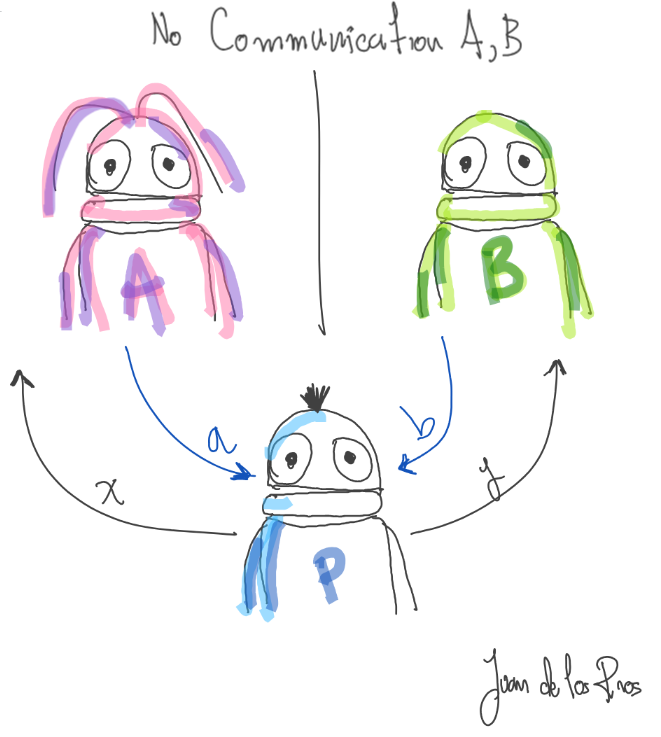

##  Goal (Police Condition)

The police checks whether their answers are **consistent**:

$$
a \oplus b = x \cdot y
$$

###  Conditions Table

| $x$ | $y$ | $x \cdot y$ | Required relation between $a$ and $b$ |
|-----|-----|------------|----------------------------------------|
| 0   | 0   | 0          | Same ($a = b$)                         |
| 0   | 1   | 0          | Same ($a = b$)                         |
| 1   | 0   | 0          | Same ($a = b$)                         |
| 1   | 1   | 1          | Different ($a \neq b$)                 |

---

###  Interpretation

- In **3 out of 4 cases**, they must give the **same answer**
- In **1 case**, they must give **different answers**

##  Classical Strategy and Its Limitation

Before the interrogation, Alice and Bob can agree on a **deterministic strategy** (a fixed alibi):

- Alice decides her answers in advance:
  - $a(0)$ for $x=0$
  - $a(1)$ for $x=1$

- Bob decides his answers:
  - $b(0)$ for $y=0$
  - $b(1)$ for $y=1$

So the strategy is fully determined by:
$$
a(0),\; a(1),\; b(0),\; b(1) \in \{0,1\}
$$

---

##  Imposed Conditions

From the game rules, they must satisfy:

- For $(x,y) = (0,0)$:
  $$
  a(0) \oplus b(0) = 0 \;\Rightarrow\; a(0) = b(0)
  $$

- For $(0,1)$:
  $$
  a(0) \oplus b(1) = 0 \;\Rightarrow\; a(0) = b(1)
  $$

- For $(1,0)$:
  $$
  a(1) \oplus b(0) = 0 \;\Rightarrow\; a(1) = b(0)
  $$

- For $(1,1)$:
  $$
  a(1) \oplus b(1) = 1 \;\Rightarrow\; a(1) \neq b(1)
  $$

---

## Deriving the Contradiction

From the first three conditions:

- $a(0) = b(0)$  
- $a(0) = b(1)$  
- $a(1) = b(0)$  

 Therefore:
$$
a(0) = a(1) = b(0) = b(1)
$$

This implies:
$$
a(1) = b(1)
$$

---

## Contradiction

But the last condition requires:
$$
a(1) \neq b(1)
$$

❌ Contradiction!

---


## 7. Best Classical Strategy

For example:

$$
a = 0
$$

$$
b = 0
$$

Results:

| x | y | $a \oplus b$ | $x \cdot y$ | win |
|---|---|---|---|---|
|0|0|0|0|✔|
|0|1|0|0|✔|
|1|0|0|0|✔|
|1|1|0|1|✘|

The players win **3 out of 4 cases**.

##  Classical Limit: Maximum Success Probability

We now show that the **maximum success probability in any classical strategy is 75%**.

---


## Success Probability

The inputs $(x,y)$ are chosen **uniformly at random**, so each case has probability:

$$
P(x,y) = \frac{1}{4}
$$

If a strategy satisfies at most 3 cases:

$$
P_{\text{win}} \leq \frac{3}{4}
$$


##  Final Result

$$
P_{\text{classical}}^{\max} = \frac{3}{4} = 75\%
$$

---

## 💡 Interpretation

Even with the best possible classical strategy:

> Alice and Bob cannot win all rounds — one case will always fail.

In [ ]:
import random  # Library used to generate random numbers

def chsh_classical_round():
    """
    Simulates one round of the classical CHSH game.

    The referee sends two random bits:
    x -> to Alice
    y -> to Bob

    Alice and Bob respond with bits a and b according to a fixed classical strategy.
    The function returns True if the players win the round and False otherwise.
    """

    # The referee generates random bits for Alice and Bob
    x = random.randint(0,1)   # Bit sent to Alice
    y = random.randint(0,1)   # Bit sent to Bob

    # Classical strategy
    # In this simple strategy both players always answer 0
    a = 0   # Alice's answer
    b = 0   # Bob's answer

    # CHSH winning condition
    # Players win if:
    # a XOR b = x AND y
    #
    # ^  -> XOR (addition modulo 2)
    # &  -> logical AND
    win = (a ^ b) == (x & y)

    # Return True if the players win the round
    return win

In [ ]:
shots = 1000000

wins = 0

for _ in range(shots):
    if chsh_classical_round():
        wins += 1

print("Probability of winning:", wins/shots)

Probability of winning: 0.750414


# CHSH Game – Quantum Case

A natural question to ask at this point is whether Alice and Bob can do any better using a quantum strategy. In particular, if they share an entangled quantum state as the following figure suggests, which they could have prepared prior to playing the game, can they increase their winning probability?

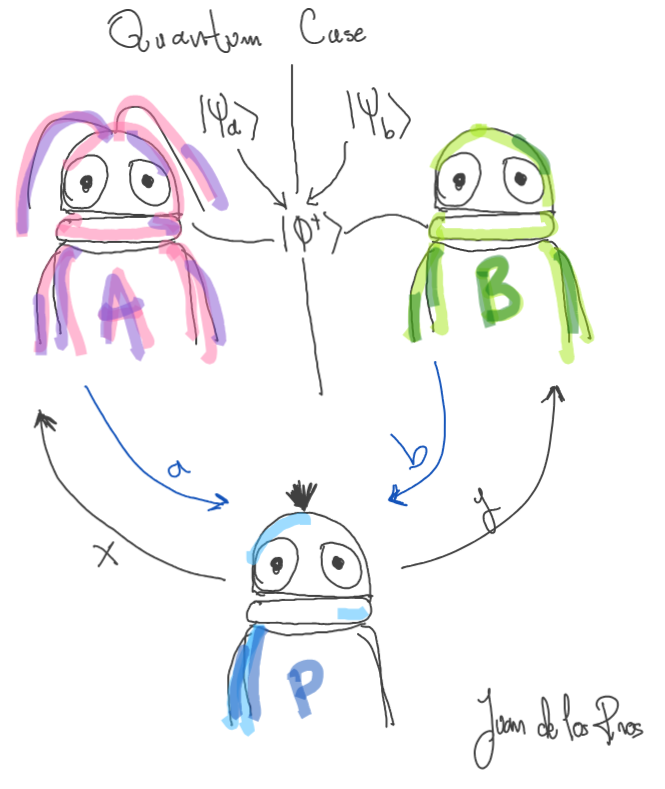

## Quantum Strategy

If Alice and Bob share an entangled state (typically the Bell state $|\Phi^+\rangle$), they can perform measurements at specific angles:

- Alice: $0$, $\pi/4$  
- Bob: $\pi/8$, $-\pi/8$  

This leads to a higher winning probability:

$$
P_{\text{quantum}} = \frac{2 + \sqrt{2}}{4} \approx 0.8536
$$

and a violation of the CHSH inequality:

$$
|S| = 2\sqrt{2}
$$

---

## Physical Meaning

The violation of the CHSH inequality demonstrates that quantum correlations cannot be explained by any local hidden variable theory.

This is a direct manifestation of:

- Quantum entanglement  
- Non-local correlations  
- The limits of classical physics  

---

In [ ]:
!pip install qiskit qiskit-aer matplotlib

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

In [ ]:
# Initialize quantum simulator backend (statevector / shot-based simulation)
simulator = AerSimulator()

In [ ]:
def apply_u_theta(circuit, qubit, theta):
    """
    Apply the unitary rotation U_theta to a given qubit.

    Theoretical form:
        U_θ = [[cos(θ), sin(θ)],
               [-sin(θ), cos(θ)]]

    In Qiskit, this transformation is implemented as a Y-rotation:
        RY(-2θ)

    This rotation defines the measurement basis for each player.
    """
    circuit.ry(-2*theta, qubit)

In [ ]:
def create_chsh_circuit(x, y):
    """
    Construct the CHSH circuit for a given pair of inputs (x, y).

    Steps:
    1. Prepare a maximally entangled Bell state |Φ+⟩
    2. Apply measurement-dependent rotations (Alice and Bob strategies)
    3. Measure both qubits in the computational basis

    Inputs:
        x (int): Alice's question (0 or 1)
        y (int): Bob's question (0 or 1)

    Output:
        QuantumCircuit ready for execution
    """
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    circuit = QuantumCircuit(qr, cr)

    # Step 1: Create Bell state |Φ+⟩ = (|00⟩ + |11⟩)/√2
    circuit.h(0)
    circuit.cx(0, 1)

    # Step 2: Alice's measurement basis (depends on x)
    if x == 0:
        apply_u_theta(circuit, 0, 0)           # Measurement along Z basis
    else:
        apply_u_theta(circuit, 0, np.pi/4)     # Rotated basis

    # Step 3: Bob's measurement basis (depends on y)
    if y == 0:
        apply_u_theta(circuit, 1, np.pi/8)     # Optimal CHSH angle
    else:
        apply_u_theta(circuit, 1, -np.pi/8)    # Opposite rotation

    # Step 4: Measure both qubits
    circuit.measure([0, 1], [0, 1])

    return circuit

In [ ]:
!pip install pylatexenc

In [ ]:
for x, y in [(0,0), (0,1), (1,0), (1,1)]:
    print(f"\nCircuit for (x,y)=({x},{y})")
    print(create_chsh_circuit(x, y).draw())


Circuit for (x,y)=(0,0)
     ┌───┐      ┌───────┐  ┌─┐   
q_0: ┤ H ├──■───┤ Ry(0) ├──┤M├───
     └───┘┌─┴─┐┌┴───────┴─┐└╥┘┌─┐
q_1: ─────┤ X ├┤ Ry(-π/4) ├─╫─┤M├
          └───┘└──────────┘ ║ └╥┘
c: 2/═══════════════════════╩══╩═
                            0  1 

Circuit for (x,y)=(0,1)
     ┌───┐      ┌───────┐ ┌─┐   
q_0: ┤ H ├──■───┤ Ry(0) ├─┤M├───
     └───┘┌─┴─┐┌┴───────┴┐└╥┘┌─┐
q_1: ─────┤ X ├┤ Ry(π/4) ├─╫─┤M├
          └───┘└─────────┘ ║ └╥┘
c: 2/══════════════════════╩══╩═
                           0  1 

Circuit for (x,y)=(1,0)
     ┌───┐     ┌──────────┐┌─┐   
q_0: ┤ H ├──■──┤ Ry(-π/2) ├┤M├───
     └───┘┌─┴─┐├──────────┤└╥┘┌─┐
q_1: ─────┤ X ├┤ Ry(-π/4) ├─╫─┤M├
          └───┘└──────────┘ ║ └╥┘
c: 2/═══════════════════════╩══╩═
                            0  1 

Circuit for (x,y)=(1,1)
     ┌───┐     ┌──────────┐┌─┐   
q_0: ┤ H ├──■──┤ Ry(-π/2) ├┤M├───
     └───┘┌─┴─┐├─────────┬┘└╥┘┌─┐
q_1: ─────┤ X ├┤ Ry(π/4) ├──╫─┤M├
          └───┘└─────────┘  ║ └╥┘
c: 2/══════════════════

In [ ]:
def calculate_win_probability(counts, shots, x, y):
    """
    Compute the CHSH game winning probability.

    Winning condition:
        a ⊕ b = x ⋅ y

    For each measurement outcome:
        - Extract bits a and b
        - Check if the CHSH condition is satisfied
        - Count successful events

    Returns:
        Probability of winning for given (x, y)
    """
    wins = 0
    for outcome, count in counts.items():
        # Extract measurement bits (note: Qiskit uses little-endian ordering)
        a = int(outcome[0])
        b = int(outcome[1])

        # Check CHSH winning condition
        if (a ^ b) == (x & y):
            wins += count

    return wins / shots

In [ ]:
def calculate_correlation(counts, shots):
    """
    Compute correlation function:
        E(x,y) = P(equal outcomes) - P(different outcomes)

    Where:
        equal     → '00' or '11'
        different → '01' or '10'

    This quantity is used to compute the CHSH parameter S.
    """
    equal = counts.get('00', 0) + counts.get('11', 0)
    different = counts.get('01', 0) + counts.get('10', 0)

    if shots > 0:
        correlation = (equal - different) / shots
    else:
        correlation = 0

    return correlation

In [ ]:
def run_chsh_game(num_shots=8192):
    """
    Execute the full CHSH game simulation.

    Procedure:
    - Evaluate all four input combinations (x,y)
    - Build and run circuits
    - Compute:
        • Winning probabilities
        • Correlation values E(x,y)
        • CHSH parameter S

    Also compares results against:
        - Classical bound (75%)
        - Quantum bound (~85%)
        - Bell inequality (|S| ≤ 2 classical, ≤ 2√2 quantum)
    """
    questions = [(0,0), (0,1), (1,0), (1,1)]
    win_probabilities = {}
    correlations = {}

    print("=" * 70)
    print("CHSH GAME - QUANTUM STRATEGY")
    print("=" * 70)
    print("Strategy:")
    print("  Alice: U_0 for x=0, U_{π/4} for x=1")
    print("  Bob:   U_{π/8} for y=0, U_{-π/8} for y=1")
    print("-" * 70)

    total_wins = 0

    for x, y in questions:
        # Build circuit for given inputs
        circuit = create_chsh_circuit(x, y)

        # Execute circuit on simulator
        job = simulator.run(circuit, shots=num_shots)
        counts = job.result().get_counts(circuit)

        key = f"({x},{y})"

        # Compute winning probability
        win_prob = calculate_win_probability(counts, num_shots, x, y)
        win_probabilities[key] = win_prob

        # Compute correlation value
        corr = calculate_correlation(counts, num_shots)
        correlations[key] = corr

        total_wins += win_prob * num_shots

        print(f"\nQuestions {key}:")
        print(f"  Results: {counts}")
        print(f"  Win probability = {win_prob:.4f}")
        print(f"  Correlation E{key} = {corr:.4f}")

    # Average winning probability over all inputs
    total_win_prob = total_wins / (4 * num_shots)

    # Compute CHSH parameter S
    E00 = correlations['(0,0)']
    E01 = correlations['(0,1)']
    E10 = correlations['(1,0)']
    E11 = correlations['(1,1)']
    S = E00 + E01 + E10 - E11

    print("\n" + "=" * 70)
    print("FINAL RESULTS")
    print("=" * 70)

    print("\nWINNING PROBABILITIES:")
    for key, prob in win_probabilities.items():
        print(f"  P(win|{key}) = {prob:.4f}")

    print("\nCORRELATIONS E(x,y) = P(equal) - P(different):")
    for key, corr in correlations.items():
        print(f"  E{key} = {corr:.4f}")

    print("\nCHSH VALUE:")
    print(f"  S = {S:.4f}")

    print("-" * 70)
    print(f"Average win probability = {total_win_prob:.4f}")

    # Theoretical limits
    classical_limit = 0.75
    quantum_limit = (2 + np.sqrt(2)) / 4

    print(f"\nLIMITS:")
    print(f"  Classical limit: {classical_limit:.4f}")
    print(f"  Quantum limit: {quantum_limit:.4f}")
    print(f"  CHSH classical bound: |S| ≤ 2")
    print(f"  CHSH quantum bound: |S| ≤ 2√2 ≈ 2.828")
    print("-" * 70)

    # Check quantum advantage
    if total_win_prob > classical_limit:
        print(f"✓ QUANTUM ADVANTAGE: {total_win_prob - classical_limit:.4f} above classical limit")

    # Check Bell inequality violation
    if abs(S) > 2:
        print(f"✓ BELL INEQUALITY VIOLATION: |S| = {abs(S):.4f} > 2")
    else:
        print(f"✗ No Bell violation: |S| = {abs(S):.4f} ≤ 2")

    return win_probabilities, correlations, total_win_prob, S

In [ ]:
# Set seed for reproducibility (only affects classical randomness, not quantum sampling)
np.random.seed(42)

# Run simulation with high number of shots for statistical accuracy
win_probs, correlations, total_win_prob, S = run_chsh_game(num_shots=181920)

CHSH GAME - QUANTUM STRATEGY
Strategy:
  Alice: U_0 for x=0, U_{π/4} for x=1
  Bob:   U_{π/8} for y=0, U_{-π/8} for y=1
----------------------------------------------------------------------

Questions (0,0):
  Results: {'01': 13351, '10': 13536, '00': 77115, '11': 77918}
  Win probability = 0.8522
  Correlation E(0,0) = 0.7044

Questions (0,1):
  Results: {'01': 13206, '11': 77840, '10': 13310, '00': 77564}
  Win probability = 0.8542
  Correlation E(0,1) = 0.7085

Questions (1,0):
  Results: {'01': 13279, '11': 77138, '10': 13337, '00': 78166}
  Win probability = 0.8537
  Correlation E(1,0) = 0.7074

Questions (1,1):
  Results: {'11': 13266, '01': 77670, '10': 77661, '00': 13323}
  Win probability = 0.8538
  Correlation E(1,1) = -0.7077

FINAL RESULTS

WINNING PROBABILITIES:
  P(win|(0,0)) = 0.8522
  P(win|(0,1)) = 0.8542
  P(win|(1,0)) = 0.8537
  P(win|(1,1)) = 0.8538

CORRELATIONS E(x,y) = P(equal) - P(different):
  E(0,0) = 0.7044
  E(0,1) = 0.7085
  E(1,0) = 0.7074
  E(1,1) = -0.7

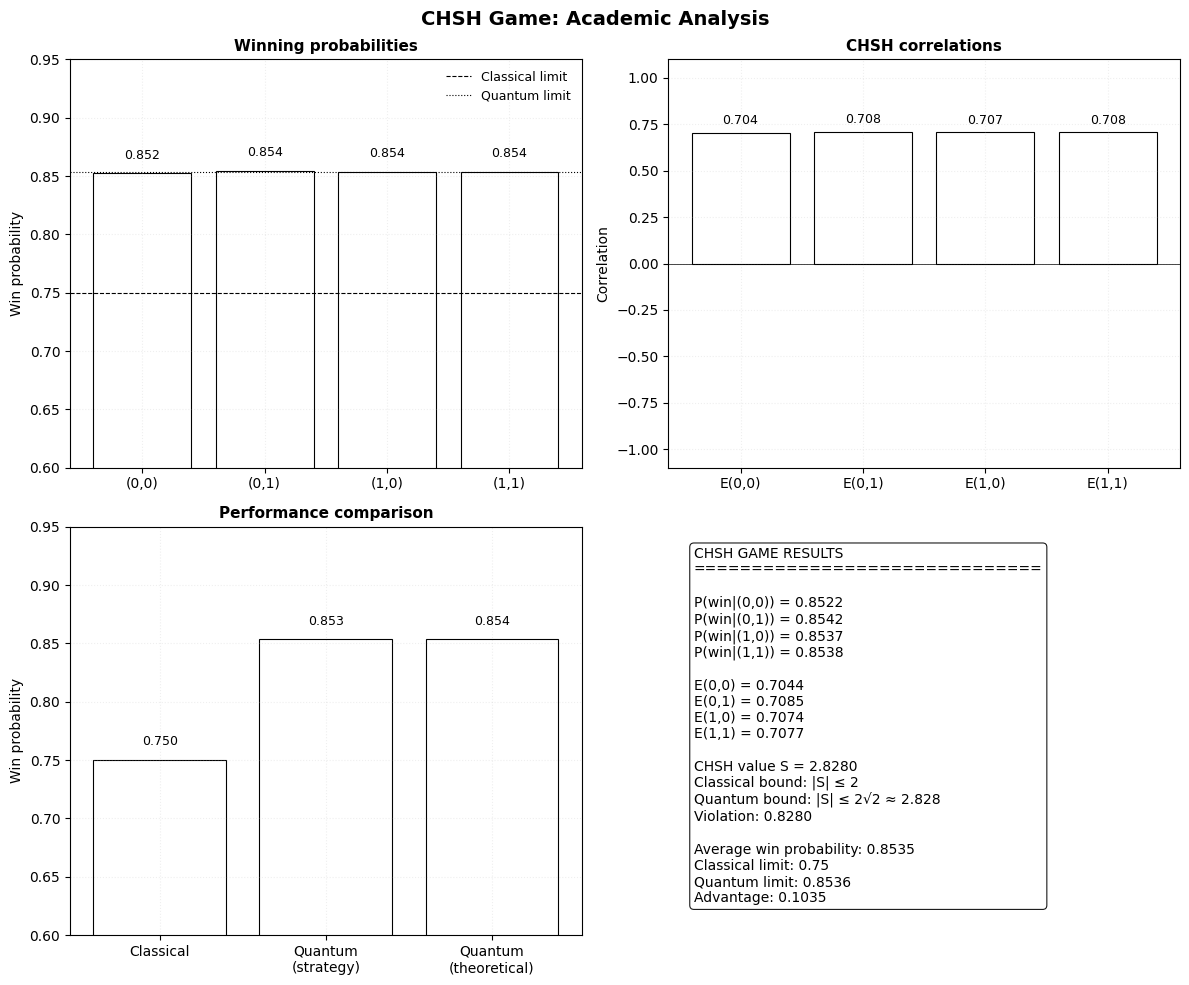

In [ ]:
import matplotlib.pyplot as plt

def plot_summary_bw_elegant_signed(win_probs, total_win_prob, S):
    """
    Generate an elegant black-and-white summary plot of the CHSH results.

    Features:
    - Clean academic style (no colors, thin lines)
    - Signed correlations (negative values extend downward)
    - Comparison with classical and quantum limits
    - Text panel with full numerical results
    """

    # Set global plotting style (minimalist / academic look)
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.8

    # Create 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Extract probabilities from dictionary
    questions = list(win_probs.keys())
    probs = list(win_probs.values())

    # Assign probabilities to each CHSH input
    p00, p01, p10, p11 = probs

    # Convert probabilities to correlation values:
    # E(x,y) = 2P(win) - 1 (valid for CHSH optimal strategy)
    E00, E01, E10, E11 = [2*p - 1 for p in probs]

    # --------------------------------------------------
    # 1. Winning probabilities per input (x,y)
    # --------------------------------------------------
    ax = axes[0, 0]

    # Bar plot (outline only for clean style)
    bars1 = ax.bar(questions, probs, fill=False, edgecolor='black', linewidth=0.8)

    # Reference lines: classical and quantum limits
    ax.axhline(y=0.75, color='black', linestyle='--', linewidth=0.8, label='Classical limit')
    ax.axhline(y=0.8536, color='black', linestyle=':', linewidth=0.8, label='Quantum limit')

    ax.set_ylabel('Win probability', fontsize=10)
    ax.set_title('Winning probabilities', fontsize=11, fontweight='bold')
    ax.set_ylim(0.6, 0.95)

    # Add legend without frame (clean look)
    ax.legend(frameon=False, fontsize=9)

    # Light grid for readability
    ax.grid(True, alpha=0.2, linestyle=':')

    # Annotate each bar with its numerical value
    for bar, prob in zip(bars1, probs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{prob:.3f}', ha='center', va='bottom', fontsize=9)

    # --------------------------------------------------
    # 2. Correlation values E(x,y)
    # --------------------------------------------------
    ax = axes[0, 1]

    corr_labels = ['E(0,0)', 'E(0,1)', 'E(1,0)', 'E(1,1)']
    corr_values = [E00, E01, E10, E11]

    # Plot each correlation as a signed bar
    for i, val in enumerate(corr_values):
        ax.bar(corr_labels[i], val, fill=False, edgecolor='black', linewidth=0.8)

        # Position label depending on sign
        y_pos = val + 0.03 if val >= 0 else val - 0.05
        va = 'bottom' if val >= 0 else 'top'

        ax.text(i, y_pos, f'{val:.3f}', ha='center', va=va, fontsize=9)

    # Horizontal zero line for reference
    ax.axhline(0, color='black', linewidth=0.5)

    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title('CHSH correlations', fontsize=11, fontweight='bold')
    ax.set_ylim(-1.1, 1.1)

    # Light grid
    ax.grid(True, alpha=0.2, linestyle=':')

    # --------------------------------------------------
    # 3. Performance comparison (classical vs quantum)
    # --------------------------------------------------
    ax = axes[1, 0]

    limits = ['Classical', 'Quantum\n(strategy)', 'Quantum\n(theoretical)']
    limit_values = [0.75, total_win_prob, 0.8536]

    bars3 = ax.bar(limits, limit_values, fill=False, edgecolor='black', linewidth=0.8)

    ax.set_ylabel('Win probability', fontsize=10)
    ax.set_title('Performance comparison', fontsize=11, fontweight='bold')
    ax.set_ylim(0.6, 0.95)

    ax.grid(True, alpha=0.2, linestyle=':')

    # Annotate bars
    for bar, val in zip(bars3, limit_values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    # --------------------------------------------------
    # 4. Text summary panel (CHSH results)
    # --------------------------------------------------
    ax = axes[1, 1]
    ax.axis('off')  # Hide axes for text-only panel

    # Build formatted summary text
    info_text = (
        f"CHSH GAME RESULTS\n"
        f"{'='*30}\n\n"
        f"P(win|(0,0)) = {p00:.4f}\n"
        f"P(win|(0,1)) = {p01:.4f}\n"
        f"P(win|(1,0)) = {p10:.4f}\n"
        f"P(win|(1,1)) = {p11:.4f}\n\n"
        f"E(0,0) = {E00:.4f}\n"
        f"E(0,1) = {E01:.4f}\n"
        f"E(1,0) = {E10:.4f}\n"
        f"E(1,1) = {E11:.4f}\n\n"
        f"CHSH value S = {S:.4f}\n"
        f"Classical bound: |S| ≤ 2\n"
        f"Quantum bound: |S| ≤ 2√2 ≈ 2.828\n"
        f"Violation: {abs(S)-2:.4f}\n\n"
        f"Average win probability: {total_win_prob:.4f}\n"
        f"Classical limit: 0.75\n"
        f"Quantum limit: 0.8536\n"
        f"Advantage: {total_win_prob-0.75:.4f}"
    )

    # Styled textbox (clean academic style)
    props = dict(boxstyle='round', facecolor='white', edgecolor='black',
                 linewidth=0.8, alpha=0.9)

    ax.text(0.05, 0.95, info_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=props)

    # Global title
    plt.suptitle('CHSH Game: Academic Analysis', fontsize=14, fontweight='bold')

    # Adjust layout to avoid overlaps
    plt.tight_layout()

    # Render figure
    plt.show()

    return fig


# Usage example
fig3 = plot_summary_bw_elegant_signed(win_probs, total_win_prob, S)

In [ ]:
def compute_S_vs_theta(theta_values, num_shots=8192):
    """
    Compute CHSH S parameter for a range of theta values.
    Returns list of S values corresponding to each theta.
    """
    S_values = []

    for theta in theta_values:
        correlations = {}

        for x, y in [(0,0), (0,1), (1,0), (1,1)]:
            # Crear circuito con theta variable
            qr = QuantumRegister(2, 'q')
            cr = ClassicalRegister(2, 'c')
            circuit = QuantumCircuit(qr, cr)

            # Estado de Bell
            circuit.h(0)
            circuit.cx(0, 1)

            # Alice
            if x == 0:
                apply_u_theta(circuit, 0, 0)
            else:
                apply_u_theta(circuit, 0, theta)

            # Bob
            if y == 0:
                apply_u_theta(circuit, 1, theta/2)
            else:
                apply_u_theta(circuit, 1, -theta/2)

            circuit.measure([0,1],[0,1])

            job = simulator.run(circuit, shots=num_shots)
            counts = job.result().get_counts()

            correlations[(x,y)] = calculate_correlation(counts, num_shots)

        # Calcular S
        S = (correlations[(0,0)] +
             correlations[(0,1)] +
             correlations[(1,0)] -
             correlations[(1,1)])

        S_values.append(S)

    return S_values

In [ ]:
# Rango de ángulos
thetas = np.linspace(0, np.pi/2, 15)

# Calcular S para cada theta
S_sim = compute_S_vs_theta(thetas, num_shots=8192)

In [ ]:
def plot_S_comparison(thetas, S_sim):
    """
    Plot theoretical vs simulated CHSH S(theta)
    (x-axis limited to pi/4 for cleaner visualization)
    """

    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.8

    # Dominio completo (interno)
    theta_dense = np.linspace(0, np.pi, 500)
    S_theory = 3*np.cos(theta_dense) - np.cos(3*theta_dense)

    # Escalado (factor 2)
    thetas_scaled = thetas / 2
    theta_dense_scaled = theta_dense / 2

    fig, ax = plt.subplots(figsize=(8,5))

    # Curva teórica
    ax.plot(theta_dense_scaled, S_theory,
            color='black', linewidth=0.9, label='Theory')

    # Simulación
    ax.scatter(thetas_scaled, S_sim,
               color='black', s=25, label='Simulation', zorder=3)

    # Límites
    ax.axhline(2, linestyle='--', linewidth=0.8,
               color='black', label='Classical bound')
    ax.axhline(2*np.sqrt(2), linestyle=':', linewidth=0.8,
               color='black', label='Quantum bound')

    # Línea en el óptimo
    ax.axvline(np.pi/8, linewidth=0.8, color='black')

    # NUEVO: eje solo hasta π/4
    ax.set_xlim(0, np.pi/4)

    # Ticks coherentes con ese rango
    xticks = [0, np.pi/8, np.pi/4]
    xtick_labels = [
        r'$0$',
        r'$\frac{\pi}{8}$',
        r'$\frac{\pi}{4}$'
    ]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)

    # Labels
    ax.set_xlabel(r'Angle $\theta$', fontsize=10)
    ax.set_ylabel(r'CHSH value $S$', fontsize=10)
    ax.set_title('CHSH: Theory vs Simulation (Focused Range)', fontsize=12, fontweight='bold')

    ax.set_ylim(-3, 3)
    ax.grid(True, alpha=0.2, linestyle=':')
    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()

    return fig

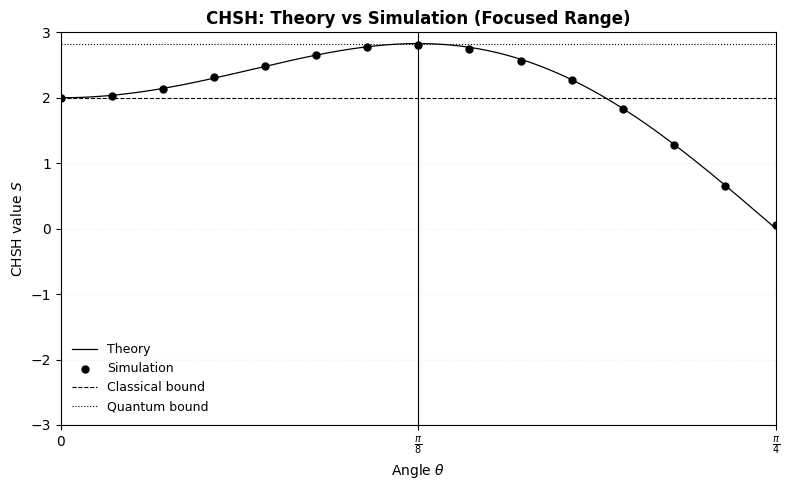

In [ ]:
fig = plot_S_comparison(thetas, S_sim)
fig.show()

In [ ]:
!pip install qiskit qiskit-ibm-runtime

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="",
    instance="",
    overwrite=True
)

In [ ]:
# =========================
# IMPORTS
# =========================

# Numerical library
import numpy as np

# Quantum circuit construction
from qiskit import QuantumCircuit

# For defining observables such as ZZ
from qiskit.quantum_info import SparsePauliOp

# Transpiler (adapts the circuit to real hardware)
from qiskit.transpiler import generate_preset_pass_manager

# Connection to IBM Quantum
from qiskit_ibm_runtime import QiskitRuntimeService

# Modern Estimator (uses expectation values instead of explicit measurement)
from qiskit_ibm_runtime import EstimatorV2 as Estimator

In [ ]:
# =========================
# BASIS ROTATION
# =========================

def apply_u_theta(qc, qubit, theta):
    """
    Applies an Ry rotation.

    This allows measurement in different bases:
    - theta = 0      → Z-basis
    - theta = pi/4   → X-basis
    - theta = ±pi/8  → Optimal intermediate CHSH bases

    Measuring in Z after this is equivalent to measuring in a rotated basis.
    """
    qc.ry(-2 * theta, qubit)

In [ ]:
# =========================
# CHSH CIRCUIT
# =========================

def create_chsh_circuit(x, y):
    """
    Constructs the circuit for the CHSH game.

    x → Alice's choice
    y → Bob's choice
    """

    # Create a 2-qubit circuit
    qc = QuantumCircuit(2)

    # =========================
    # Bell State |Φ+>
    # =========================
    qc.h(0)            # Superposition
    qc.cx(0, 1)        # Entanglement

    # =========================
    # Alice's Measurement
    # =========================
    if x == 0:
        apply_u_theta(qc, 0, 0)           # Measure in Z-basis
    else:
        apply_u_theta(qc, 0, np.pi/4)     # Measure in X-basis

    # =========================
    # Bob's Measurement
    # =========================
    if y == 0:
        apply_u_theta(qc, 1, np.pi/8)     # (Z + X)/√2 basis
    else:
        apply_u_theta(qc, 1, -np.pi/8)    # (Z - X)/√2 basis

    return qc

In [ ]:
# =========================
# WINNING PROBABILITY
# =========================

def win_probability(E, x, y):
    """
    Calculates the CHSH winning probability.

    If x·y = 0 → we want correlation
    If x·y = 1 → we want anticorrelation
    """
    return (1 + E)/2 if (x & y) == 0 else (1 - E)/2

In [ ]:
# =========================
# IBM CONNECTION
# =========================

# Load saved account
service = QiskitRuntimeService()

# Select the least busy real hardware backend
backend = service.least_busy(
    simulator=False,
    min_num_qubits=2,
    operational=True
)

print("Selected backend:", backend)

qiskit_runtime_service.__init__:WARNING:2026-03-20 17:32:22,774: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-20 17:32:23,205: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-20 17:32:24,829: Using instance: open-instance, plan: open


Selected backend: <IBMBackend('ibm_fez')>


In [ ]:
# =========================
# TRANSPILATION (0, 1, 2)
# =========================

# Dictionary to store circuits by optimization level
all_isa_circuits = {}

for opt_level in [0, 1, 2]:

    # Create pass manager with the specified optimization level
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=opt_level
    )

    isa_circuits = []

    # Transpile CHSH circuits
    for x, y in questions:
        qc = create_chsh_circuit(x, y)
        isa_qc = pm.run(qc)
        isa_circuits.append(isa_qc)

    # Store results
    all_isa_circuits[opt_level] = isa_circuits

In [ ]:
# =========================
# CREATE CIRCUITS (MULTI-OPT)
# =========================

all_isa_circuits = {}

for opt_level in [0, 1, 2]:

    # Create pass manager for this optimization level
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=opt_level
    )

    isa_circuits = []

    for x, y in questions:

        # Create ideal circuit
        qc = create_chsh_circuit(x, y)

        # Transpile using this level
        isa_qc = pm.run(qc)

        # Store transpiled circuit
        isa_circuits.append(isa_qc)

    # Store all circuits for this specific level
    all_isa_circuits[opt_level] = isa_circuits

In [ ]:
# =========================
# ESTIMATOR BY LEVEL
# =========================

results_by_level = {}

for opt_level, isa_circuits in all_isa_circuits.items():

    # Create estimator for this specific experiment
    estimator = Estimator(mode=backend)

    # Error Mitigation (Level 1: Readout Mitigation)
    estimator.options.resilience_level = 1

    # Shots per circuit
    estimator.options.default_shots = 5000

    # Define the ZZ observable (Pauli Z on both qubits)
    observable = SparsePauliOp("ZZ")

    pubs = []
    for isa_qc in isa_circuits:
        # Map the observable to the physical layout of the ISA circuit
        mapped_obs = observable.apply_layout(isa_qc.layout)
        pubs.append((isa_qc, mapped_obs))

    # Execute the job
    job = estimator.run(pubs)
    result = job.result()

    # Store raw results
    results_by_level[opt_level] = result

In [ ]:
# =========================
# PROCESS RESULTS
# =========================

# Dictionary to store processed results for each optimization level
processed_results = {}

# Iterate over each optimization level and its corresponding results
for opt_level, result in results_by_level.items():

    # Extract expectation values (correlations) <ZZ> from each result object
    # Each r.data.evs contains the measured expectation value for a circuit
    E_values = [r.data.evs for r in result]

    # Unpack the four CHSH correlators:
    # E00 = correlation for settings (0,0)
    # E01 = correlation for settings (0,1)
    # E10 = correlation for settings (1,0)
    # E11 = correlation for settings (1,1)
    E00, E01, E10, E11 = E_values

    # Compute the CHSH parameter:
    # S = E00 + E01 + E10 - E11
    # This quantity is used to test Bell inequalities
    S = E00 + E01 + E10 - E11

    # Store both the raw correlations and the computed CHSH value
    # for the current optimization level
    processed_results[opt_level] = {
        "E": E_values,  # List of expectation values
        "S": S          # Computed CHSH parameter
    }

In [ ]:
processed_results

{0: {'E': [array(0.72965433),
   array(0.77102648),
   array(0.76887728),
   array(-0.64959653)],
  'S': np.float64(2.919154611944551)},
 1: {'E': [array(0.74077555),
   array(0.80038441),
   array(0.74511074),
   array(-0.61993214)],
  'S': np.float64(2.906202835231037)},
 2: {'E': [array(0.70281738),
   array(0.71307449),
   array(0.70513505),
   array(-0.69152718)],
  'S': np.float64(2.812554096258814)}}

In [ ]:
# =========================
# WIN PROBABILITY
# =========================

# Dictionary to store win probabilities for each optimization level
win_results = {}

# Iterate over each optimization level and its processed data
for opt_level, data in processed_results.items():

    # Retrieve the expectation values (correlations) E = [E00, E01, E10, E11]
    E_values = data["E"]

    # List to store the win probability for each input pair (x, y)
    win_probs = []

    # Loop over each question pair (x, y) and its corresponding expectation value E
    for (x, y), E in zip(questions, E_values):

        # Compute the winning probability based on CHSH game rules:
        # If x AND y == 0 → players should output equal bits → use (1 + E)/2
        # If x AND y == 1 → players should output different bits → use (1 - E)/2
        p = (1 + E) / 2 if (x & y) == 0 else (1 - E) / 2

        # Store the probability for this specific input pair
        win_probs.append(p)

    # Compute the average winning probability over all 4 input pairs
    avg = sum(win_probs) / 4

    # Store detailed results for this optimization level
    win_results[opt_level] = {
        "win_probs": win_probs,  # Individual probabilities for each (x, y)
        "avg_win": avg           # Average winning probability
    }

In [ ]:
# =========================
# MODIFIED FUNCTION FOR DYNAMIC TITLE
# =========================

import matplotlib.pyplot as plt

def plot_summary_bw_elegant_signed(win_probs, total_win_prob, S, opt_level_title=None):
    """
    Elegant black-and-white summary plot of CHSH results.
    Allows dynamic title depending on the optimization level.
    """

    # Configure global matplotlib style for a clean academic look
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.8

    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Extract question labels and corresponding probabilities
    questions = list(win_probs.keys())
    probs = list(win_probs.values())

    # Unpack probabilities for each input pair (x, y)
    p00, p01, p10, p11 = probs

    # Convert probabilities to correlations using: E = 2p - 1
    E00, E01, E10, E11 = [2*p - 1 for p in probs]

    # -------------------
    # Winning probabilities plot
    # -------------------
    ax = axes[0, 0]

    # Create bar plot (black-and-white style)
    bars1 = ax.bar(questions, probs, fill=False, edgecolor='black', linewidth=0.8)

    # Add classical and quantum reference limits
    ax.axhline(y=0.75, color='black', linestyle='--', linewidth=0.8, label='Classical limit')
    ax.axhline(y=0.8536, color='black', linestyle=':', linewidth=0.8, label='Quantum limit')

    # Labels and formatting
    ax.set_ylabel('Win probability', fontsize=10)
    ax.set_title('Winning probabilities', fontsize=11, fontweight='bold')
    ax.set_ylim(0.6, 0.95)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, alpha=0.2, linestyle=':')

    # Annotate each bar with its numerical value
    for bar, prob in zip(bars1, probs):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.01,
            f'{prob:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    # -------------------
    # Correlation values plot
    # -------------------
    ax = axes[0, 1]

    # Labels and values for correlations
    corr_labels = ['E(0,0)', 'E(0,1)', 'E(1,0)', 'E(1,1)']
    corr_values = [E00, E01, E10, E11]

    # Plot each correlation as a bar
    for i, val in enumerate(corr_values):
        ax.bar(corr_labels[i], val, fill=False, edgecolor='black', linewidth=0.8)

        # Adjust label position depending on sign
        y_pos = val + 0.03 if val >= 0 else val - 0.05
        va = 'bottom' if val >= 0 else 'top'

        # Annotate value
        ax.text(i, y_pos, f'{val:.3f}', ha='center', va=va, fontsize=9)

    # Add horizontal zero reference line
    ax.axhline(0, color='black', linewidth=0.5)

    # Labels and formatting
    ax.set_ylabel('Correlation', fontsize=10)
    ax.set_title('CHSH correlations', fontsize=11, fontweight='bold')
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.2, linestyle=':')

    # -------------------
    # Performance comparison plot
    # -------------------
    ax = axes[1, 0]

    # Define comparison categories and values
    limits = ['Classical', 'Quantum\n(strategy)', 'Quantum\n(theoretical)']
    limit_values = [0.75, total_win_prob, 0.8536]

    # Plot bars
    bars3 = ax.bar(limits, limit_values, fill=False, edgecolor='black', linewidth=0.8)

    # Labels and formatting
    ax.set_ylabel('Win probability', fontsize=10)
    ax.set_title('Performance comparison', fontsize=11, fontweight='bold')
    ax.set_ylim(0.6, 0.95)
    ax.grid(True, alpha=0.2, linestyle=':')

    # Annotate each bar
    for bar, val in zip(bars3, limit_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    # -------------------
    # Text summary panel
    # -------------------
    ax = axes[1, 1]

    # Turn off axis to display only text
    ax.axis('off')

    # Create formatted summary string with all key results
    info_text = (
        f"CHSH GAME RESULTS\n"
        f"{'='*30}\n\n"
        f"P(win|(0,0)) = {p00:.4f}\n"
        f"P(win|(0,1)) = {p01:.4f}\n"
        f"P(win|(1,0)) = {p10:.4f}\n"
        f"P(win|(1,1)) = {p11:.4f}\n\n"
        f"E(0,0) = {E00:.4f}\n"
        f"E(0,1) = {E01:.4f}\n"
        f"E(1,0) = {E10:.4f}\n"
        f"E(1,1) = {E11:.4f}\n\n"
        f"CHSH value S = {S:.4f}\n"
        f"Classical bound: |S| ≤ 2\n"
        f"Quantum bound: |S| ≤ 2√2 ≈ 2.828\n"
        f"Violation: {abs(S) - 2:.4f}\n\n"
        f"Average win probability: {total_win_prob:.4f}\n"
        f"Classical limit: 0.75\n"
        f"Quantum limit: 0.8536\n"
        f"Advantage: {total_win_prob - 0.75:.4f}"
    )

    # Define text box style
    props = dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        linewidth=0.8,
        alpha=0.9
    )

    # Add text box to subplot
    ax.text(
        0.05, 0.95,
        info_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=props
    )

    # -------------------
    # Dynamic super title
    # -------------------
    if opt_level_title is not None:
        plt.suptitle(
            f'CHSH Game: Academic Analysis ({opt_level_title})',
            fontsize=14,
            fontweight='bold'
        )
    else:
        plt.suptitle(
            'CHSH Game: Academic Analysis',
            fontsize=14,
            fontweight='bold'
        )

    # Adjust layout to prevent overlaps
    plt.tight_layout()

    # Display the figure
    plt.show()

    # Return figure object for further use if needed
    return fig

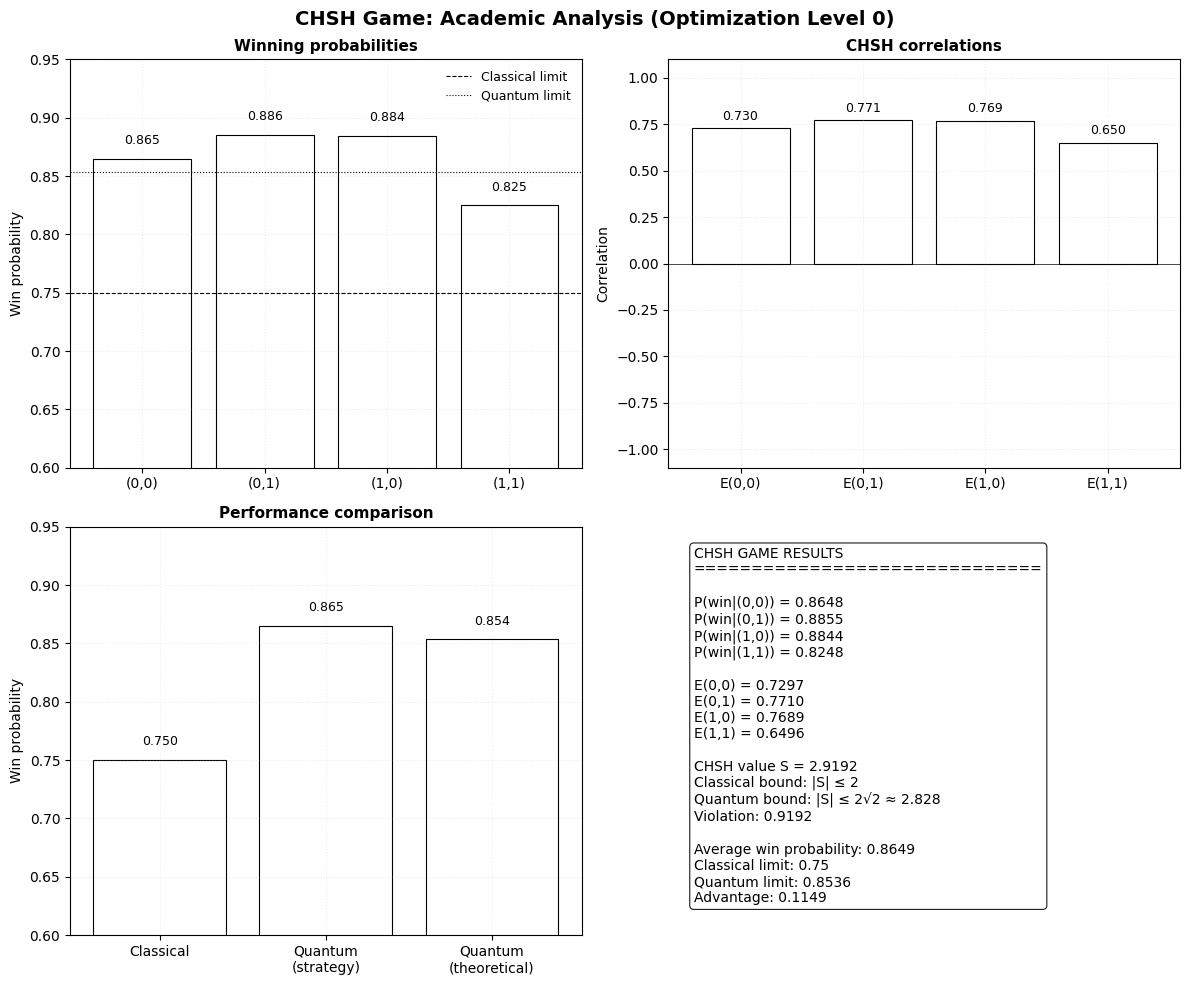

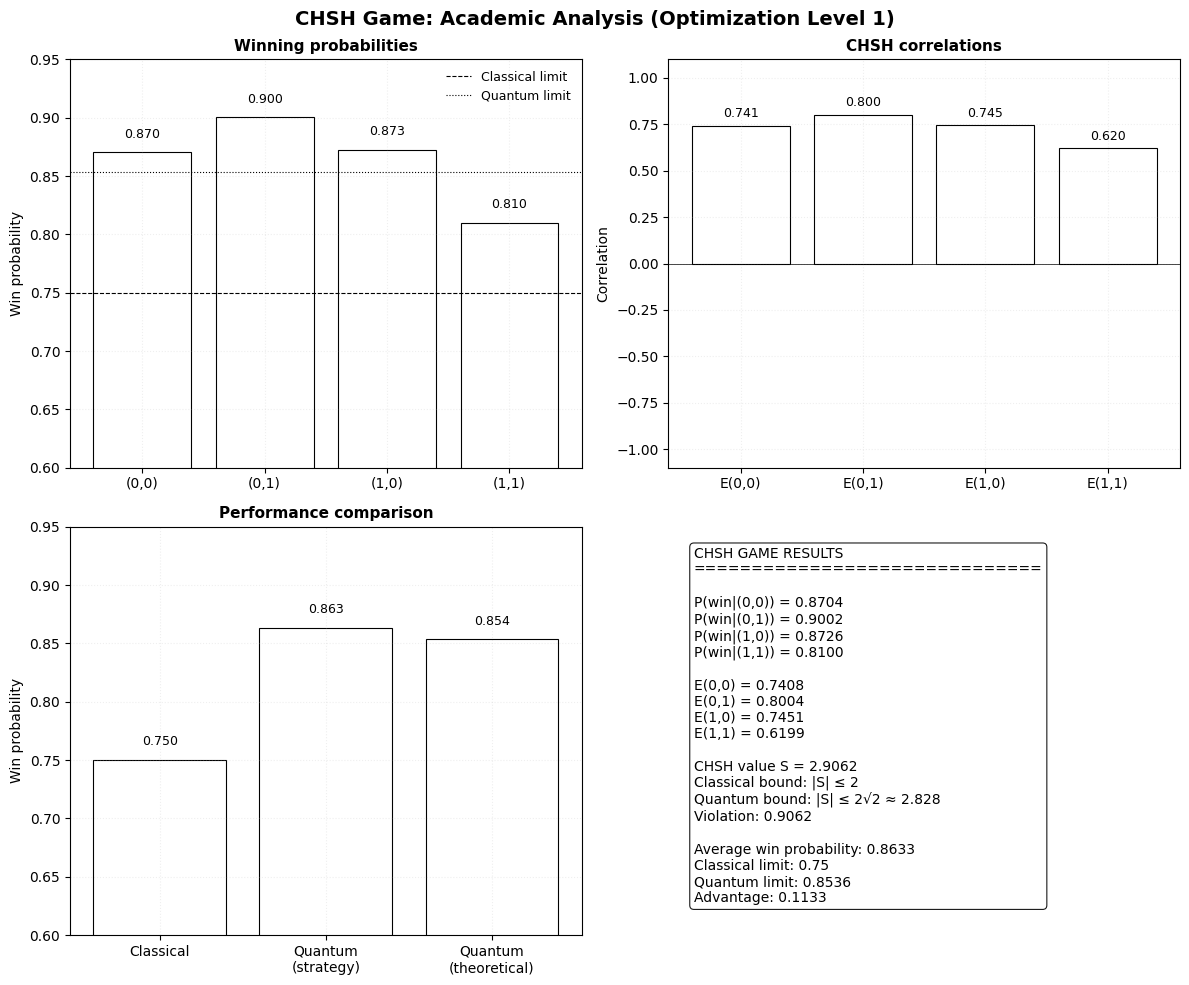

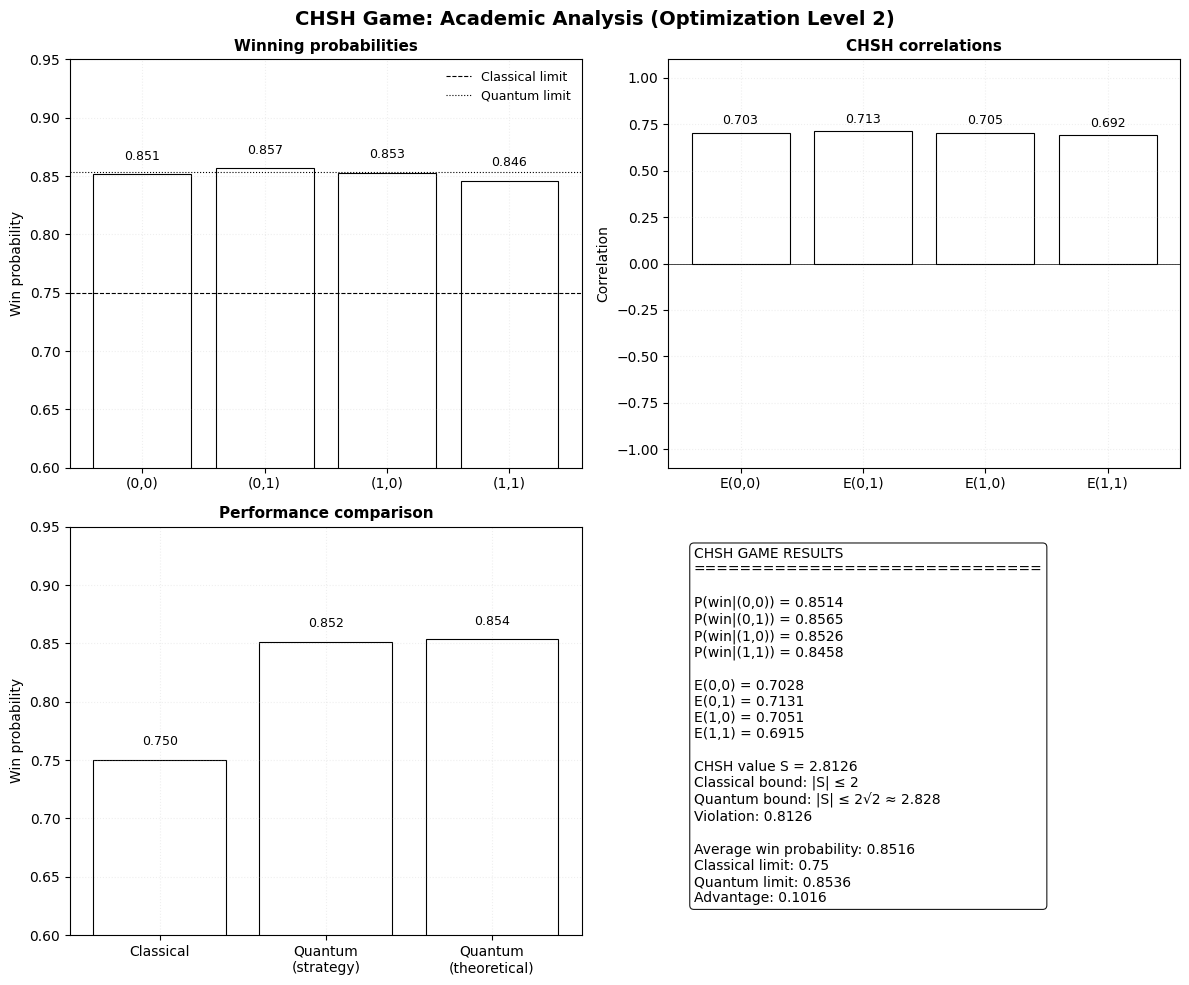

In [ ]:
# Plot each optimization level separately
for opt_level in sorted(processed_results.keys()):

    # Extract expectation values and CHSH value for this optimization level
    E_values = processed_results[opt_level]["E"]
    S = processed_results[opt_level]["S"]

    # -------------------
    # Compute win probabilities
    # -------------------

    # Dictionary to store win probabilities for each input pair (x, y)
    win_probs = {}

    # Loop over each question pair and corresponding expectation value
    for (x, y), E in zip(questions, E_values):

        # Compute win probability based on CHSH game condition:
        # If x AND y == 0 → outputs should be equal → (1 + E)/2
        # If x AND y == 1 → outputs should be different → (1 - E)/2
        p = (1 + E) / 2 if (x & y) == 0 else (1 - E) / 2

        # Store probability with a readable key format "(x,y)"
        win_probs[f"({x},{y})"] = p

    # Compute the average winning probability across all input pairs
    total_win_prob = sum(win_probs.values()) / 4

    # -------------------
    # Generate plot with dynamic title
    # -------------------

    # Call the plotting function and include the optimization level in the title
    fig = plot_summary_bw_elegant_signed(
        win_probs,
        total_win_prob,
        S,
        opt_level_title=f'Optimization Level {opt_level}'
    )

=== CHSH RESULTS SUMMARY (FROM EXISTING DATA) ===

Optimization level 0
  S = 2.919 (theory: 2.828)
  Max |ΔE| = 0.064
  Avg P(win) = 0.865 (theory: 0.8536)
    P(win|(0, 0)) = 0.865
    P(win|(0, 1)) = 0.885
    P(win|(1, 0)) = 0.884
    P(win|(1, 1)) = 0.825

Optimization level 1
  S = 2.906 (theory: 2.828)
  Max |ΔE| = 0.093
  Avg P(win) = 0.863 (theory: 0.8536)
    P(win|(0, 0)) = 0.870
    P(win|(0, 1)) = 0.900
    P(win|(1, 0)) = 0.873
    P(win|(1, 1)) = 0.810

Optimization level 2
  S = 2.813 (theory: 2.828)
  Max |ΔE| = 0.016
  Avg P(win) = 0.852 (theory: 0.8536)
    P(win|(0, 0)) = 0.851
    P(win|(0, 1)) = 0.857
    P(win|(1, 0)) = 0.853
    P(win|(1, 1)) = 0.846


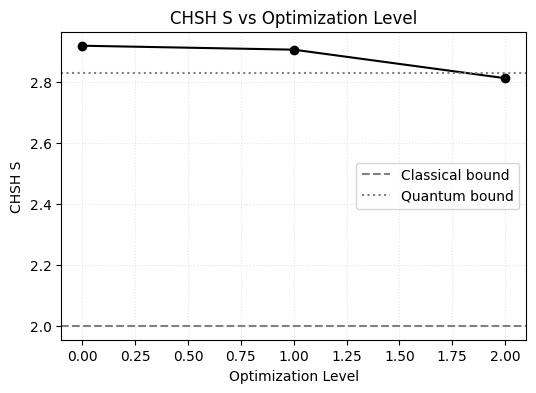

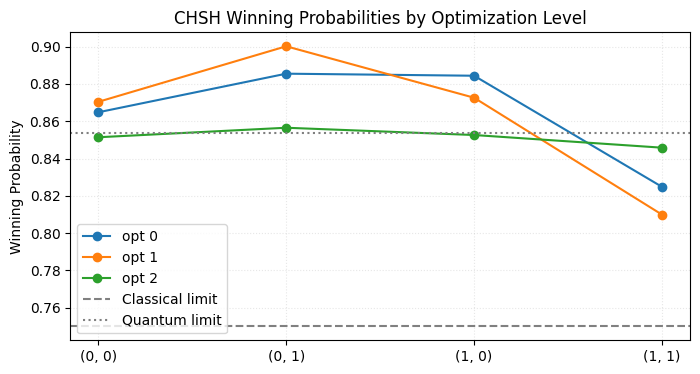

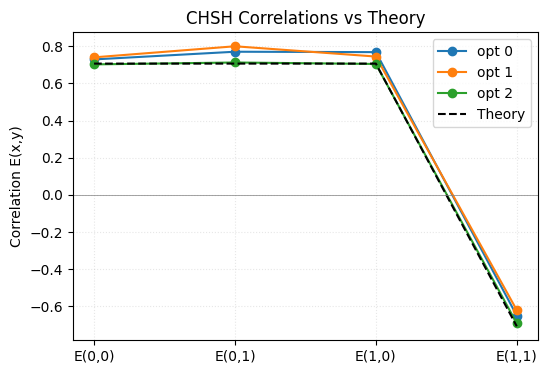

In [ ]:
# =========================
# DATA ANALYSIS USING EXISTING RESULTS
# =========================

import numpy as np
import matplotlib.pyplot as plt

# Precomputed experimental/simulation results
processed_results = {
    0: {'E': [0.72965433, 0.77102648, 0.76887728, -0.64959653], 'S': 2.91915461},
    1: {'E': [0.74077555, 0.80038441, 0.74511074, -0.61993214], 'S': 2.90620283},
    2: {'E': [0.70281738, 0.71307449, 0.70513505, -0.69152718], 'S': 2.81255410}  # Fixed closing brace
}

# Precomputed winning probabilities
win_results = {
    0: {'win_probs': [0.8648, 0.8855, 0.8844, 0.8248], 'avg_win': 0.8649},
    1: {'win_probs': [0.8704, 0.9002, 0.8726, 0.8099], 'avg_win': 0.8633},
    2: {'win_probs': [0.8514, 0.8565, 0.8526, 0.8458], 'avg_win': 0.8516}
}

# Input pairs (x, y) used in the CHSH game
questions = [(0,0), (0,1), (1,0), (1,1)]

# Theoretical quantum predictions
E_theory = [1/np.sqrt(2), 1/np.sqrt(2), 1/np.sqrt(2), -1/np.sqrt(2)]
S_theory = 2 * np.sqrt(2)
Pwin_theory = 0.8536

# =========================
# RESULTS TABLE (TEXT OUTPUT)
# =========================

print("=== CHSH RESULTS SUMMARY (FROM EXISTING DATA) ===")

# Iterate through optimization levels in order
for lvl in sorted(processed_results.keys()):

    # Extract experimental correlations and CHSH value
    E_vals = processed_results[lvl]['E']
    S = processed_results[lvl]['S']

    # Extract winning probabilities
    Pwin = win_results[lvl]['win_probs']
    avg_Pwin = win_results[lvl]['avg_win']

    # Compute maximum deviation from theoretical correlations
    max_delta_E = max(abs(np.array(E_vals) - np.array(E_theory)))

    # Print summary for this optimization level
    print(f"\nOptimization level {lvl}")
    print(f"  S = {S:.3f} (theory: {S_theory:.3f})")
    print(f"  Max |ΔE| = {max_delta_E:.3f}")
    print(f"  Avg P(win) = {avg_Pwin:.3f} (theory: {Pwin_theory})")

    # Print individual winning probabilities for each input pair
    for q, p in zip(questions, Pwin):
        print(f"    P(win|{q}) = {p:.3f}")

# =========================
# PLOTS
# =========================

# Set consistent font for all plots
plt.rcParams['font.family'] = 'DejaVu Sans'

# Sorted list of optimization levels
opt_levels = sorted(processed_results.keys())

# -------------------
#  CHSH S vs Optimization Level
# -------------------
plt.figure(figsize=(6,4))

# Extract S values for each level
S_vals = [processed_results[l]['S'] for l in opt_levels]

# Plot S values
plt.plot(opt_levels, S_vals, 'o-', color='black')

# Add classical and quantum bounds
plt.axhline(2, linestyle='--', color='gray', label='Classical bound')
plt.axhline(S_theory, linestyle=':', color='gray', label='Quantum bound')

# Labels and styling
plt.xlabel('Optimization Level')
plt.ylabel('CHSH S')
plt.title('CHSH S vs Optimization Level')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()

# Show plot
plt.show()

# -------------------
#  Winning probabilities per input pair
# -------------------
plt.figure(figsize=(8,4))

# Convert question pairs to string labels
labels = [str(q) for q in questions]

# Plot probabilities for each optimization level
for lvl in opt_levels:
    P = win_results[lvl]['win_probs']
    plt.plot(labels, P, 'o-', label=f'opt {lvl}')

# Add classical and quantum limits
plt.axhline(0.75, linestyle='--', color='gray', label='Classical limit')
plt.axhline(Pwin_theory, linestyle=':', color='gray', label='Quantum limit')

# Labels and styling
plt.ylabel('Winning Probability')
plt.title('CHSH Winning Probabilities by Optimization Level')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()

# Show plot
plt.show()

# -------------------
#  Correlations vs theoretical values
# -------------------
plt.figure(figsize=(6,4))

# Labels for correlation terms
corr_labels = ['E(0,0)','E(0,1)','E(1,0)','E(1,1)']

# Plot experimental correlations for each optimization level
for lvl in opt_levels:
    E = processed_results[lvl]['E']
    plt.plot(corr_labels, E, 'o-', label=f'opt {lvl}')

# Plot theoretical correlations as reference
plt.plot(corr_labels, E_theory, 'k--', label='Theory')

# Add zero reference line
plt.axhline(0, color='gray', linewidth=0.5)

# Labels and styling
plt.ylabel('Correlation E(x,y)')
plt.title('CHSH Correlations vs Theory')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()

# Show plot
plt.show()

=== CHSH ANALYSIS SUMMARY ===

Optimization level 0
  S = 2.919 (ΔS = -0.091 vs 2√2 ≈ 2.828)
  Max ΔE = 0.064
  Avg P(win) = 0.865 (Quantum advantage = 0.115)
    P(win|(0, 0)) = 0.865, ΔE = 0.023
    P(win|(0, 1)) = 0.885, ΔE = 0.064
    P(win|(1, 0)) = 0.884, ΔE = 0.062
    P(win|(1, 1)) = 0.825, ΔE = 0.058

Optimization level 1
  S = 2.906 (ΔS = -0.078 vs 2√2 ≈ 2.828)
  Max ΔE = 0.093
  Avg P(win) = 0.863 (Quantum advantage = 0.113)
    P(win|(0, 0)) = 0.870, ΔE = 0.034
    P(win|(0, 1)) = 0.900, ΔE = 0.093
    P(win|(1, 0)) = 0.873, ΔE = 0.038
    P(win|(1, 1)) = 0.810, ΔE = 0.087

Optimization level 2
  S = 2.813 (ΔS = 0.016 vs 2√2 ≈ 2.828)
  Max ΔE = 0.016
  Avg P(win) = 0.852 (Quantum advantage = 0.102)
    P(win|(0, 0)) = 0.851, ΔE = 0.004
    P(win|(0, 1)) = 0.857, ΔE = 0.006
    P(win|(1, 0)) = 0.853, ΔE = 0.002
    P(win|(1, 1)) = 0.846, ΔE = 0.016


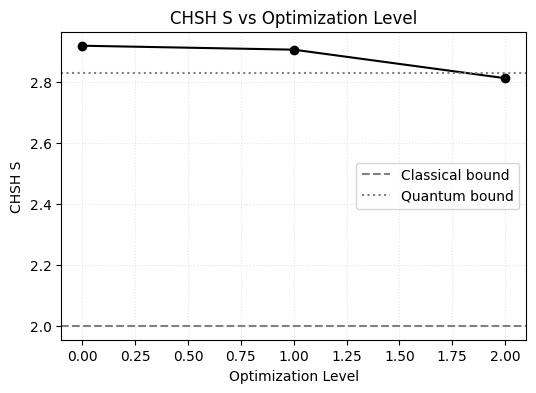

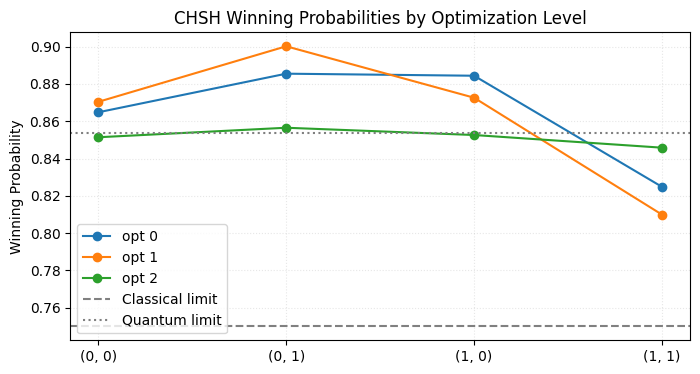

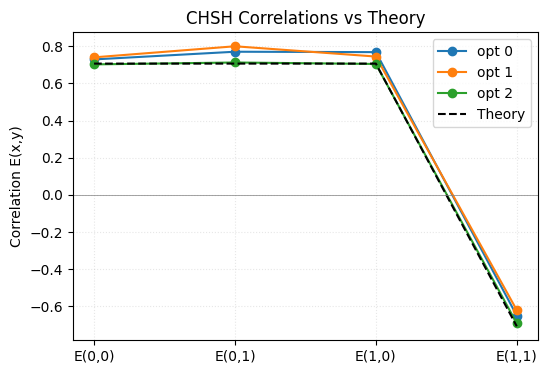

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

# Existing (precomputed) data
processed_results = {
    0: {'E': [0.72965433, 0.77102648, 0.76887728, -0.64959653], 'S': 2.91915461},
    1: {'E': [0.74077555, 0.80038441, 0.74511074, -0.61993214], 'S': 2.90620283},
    2: {'E': [0.70281738, 0.71307449, 0.70513505, -0.69152718], 'S': 2.81255410}
}

# Precomputed winning probabilities
win_results = {
    0: {'win_probs': [0.8648, 0.8855, 0.8844, 0.8248], 'avg_win': 0.8649},
    1: {'win_probs': [0.8704, 0.9002, 0.8726, 0.8099], 'avg_win': 0.8633},
    2: {'win_probs': [0.8514, 0.8565, 0.8526, 0.8458], 'avg_win': 0.8516}
}

# CHSH input pairs
questions = [(0,0), (0,1), (1,0), (1,1)]

# Theoretical quantum predictions
E_theory = [1/np.sqrt(2)] * 3 + [-1/np.sqrt(2)]
S_theory = 2 * np.sqrt(2)
Pwin_theory = 0.8536
classical_limit = 0.75

# =========================
# ANALYSIS COMPUTATIONS
# =========================

# Dictionary to store derived analysis metrics
analysis_results = {}

# Iterate over each optimization level
for lvl in processed_results:

    # Convert correlation values to numpy array for vectorized operations
    E_vals = np.array(processed_results[lvl]['E'])

    # Extract CHSH value
    S_val = processed_results[lvl]['S']

    # Convert win probabilities to numpy array
    Pwin_vals = np.array(win_results[lvl]['win_probs'])

    # Average win probability
    avg_Pwin = win_results[lvl]['avg_win']

    # Compute deviation from theoretical correlations
    delta_E = np.abs(E_vals - np.array(E_theory))

    # Difference between theoretical and observed CHSH value
    delta_S = S_theory - S_val

    # Quantum advantage over classical limit
    quantum_advantage = avg_Pwin - classical_limit

    # Store all computed metrics
    analysis_results[lvl] = {
        'E_vals': E_vals,
        'delta_E': delta_E,
        'S': S_val,
        'delta_S': delta_S,
        'Pwin_vals': Pwin_vals,
        'avg_Pwin': avg_Pwin,
        'quantum_advantage': quantum_advantage
    }

# =========================
# SUMMARY TABLE (TEXT OUTPUT)
# =========================

print("=== CHSH ANALYSIS SUMMARY ===")

# Print analysis for each optimization level
for lvl, stats in analysis_results.items():

    print(f"\nOptimization level {lvl}")
    print(f"  S = {stats['S']:.3f} (ΔS = {stats['delta_S']:.3f} vs 2√2 ≈ {S_theory:.3f})")
    print(f"  Max ΔE = {np.max(stats['delta_E']):.3f}")
    print(f"  Avg P(win) = {stats['avg_Pwin']:.3f} (Quantum advantage = {stats['quantum_advantage']:.3f})")

    # Print detailed per-input results
    for q, p, dE in zip(questions, stats['Pwin_vals'], stats['delta_E']):
        print(f"    P(win|{q}) = {p:.3f}, ΔE = {dE:.3f}")

# =========================
# PLOTS
# =========================

# Sorted optimization levels
opt_levels = sorted(analysis_results.keys())

# -------------------
#  CHSH S vs Optimization Level
# -------------------
plt.figure(figsize=(6,4))

# Extract S values
S_vals = [analysis_results[l]['S'] for l in opt_levels]

# Plot
plt.plot(opt_levels, S_vals, 'o-', color='black')

# Reference bounds
plt.axhline(2, linestyle='--', color='gray', label='Classical bound')
plt.axhline(S_theory, linestyle=':', color='gray', label='Quantum bound')

# Labels and styling
plt.xlabel('Optimization Level')
plt.ylabel('CHSH S')
plt.title('CHSH S vs Optimization Level')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()
plt.show()

# -------------------
#  Winning probabilities vs classical limit
# -------------------
plt.figure(figsize=(8,4))

# Convert input pairs to string labels
labels = [str(q) for q in questions]

# Plot each optimization level
for lvl in opt_levels:
    P = analysis_results[lvl]['Pwin_vals']
    plt.plot(labels, P, 'o-', label=f'opt {lvl}')

# Reference lines
plt.axhline(classical_limit, linestyle='--', color='gray', label='Classical limit')
plt.axhline(Pwin_theory, linestyle=':', color='gray', label='Quantum limit')

# Labels and styling
plt.ylabel('Winning Probability')
plt.title('CHSH Winning Probabilities by Optimization Level')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()
plt.show()

# -------------------
# Correlations vs theory
# -------------------
plt.figure(figsize=(6,4))

# Labels for correlations
corr_labels = ['E(0,0)','E(0,1)','E(1,0)','E(1,1)']

# Plot experimental correlations
for lvl in opt_levels:
    E = analysis_results[lvl]['E_vals']
    plt.plot(corr_labels, E, 'o-', label=f'opt {lvl}')

# Plot theoretical reference
plt.plot(corr_labels, E_theory, 'k--', label='Theory')

# Zero reference line
plt.axhline(0, color='gray', linewidth=0.5)

# Labels and styling
plt.ylabel('Correlation E(x,y)')
plt.title('CHSH Correlations vs Theory')
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend()
plt.show()


=== Nivel de optimización 0 ===

--- Inputs (x=0, y=0) ---


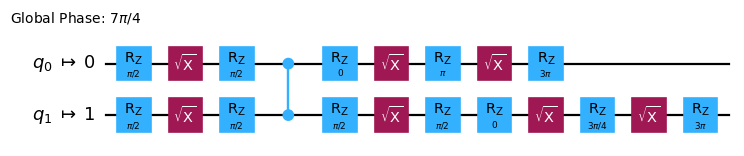

--- Inputs (x=0, y=1) ---


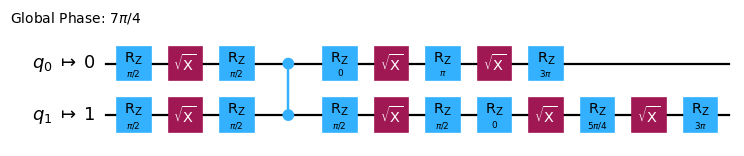

--- Inputs (x=1, y=0) ---


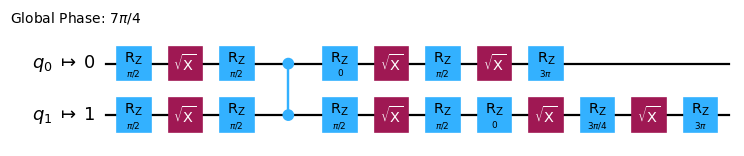

--- Inputs (x=1, y=1) ---


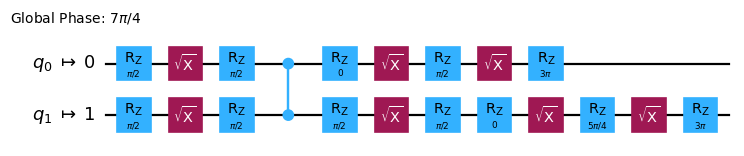


=== Nivel de optimización 1 ===

--- Inputs (x=0, y=0) ---


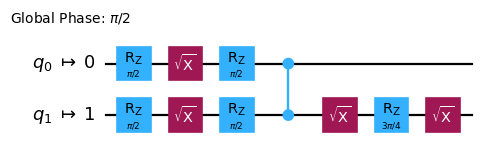

--- Inputs (x=0, y=1) ---


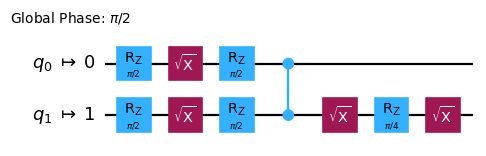

--- Inputs (x=1, y=0) ---


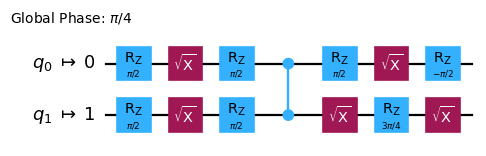

--- Inputs (x=1, y=1) ---


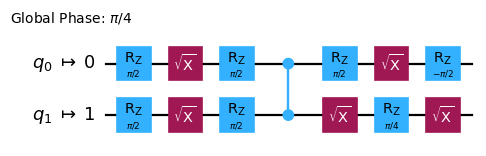


=== Nivel de optimización 2 ===

--- Inputs (x=0, y=0) ---


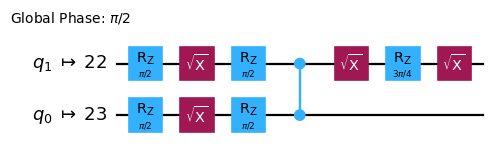

--- Inputs (x=0, y=1) ---


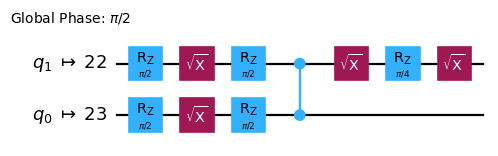

--- Inputs (x=1, y=0) ---


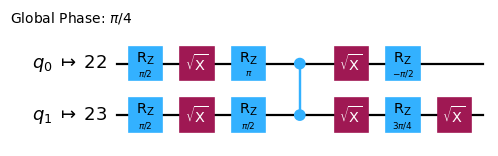

--- Inputs (x=1, y=1) ---


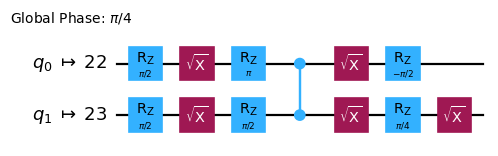

In [ ]:
# Import required Qiskit tools for transpilation and visualization
from qiskit import transpile
from qiskit.visualization import plot_circuit_layout, circuit_drawer
from IPython.display import display

# Iterate over different optimization levels
for opt_level in [0, 1, 2]:

    # Print header for current optimization level
    print(f"\n=== Optimization Level {opt_level} ===\n")

    # Loop over all CHSH input pairs (x, y)
    for i, (x, y) in enumerate(questions):

        # Display current input configuration
        print(f"--- Inputs (x={x}, y={y}) ---")

        # -------------------
        # Create original quantum circuit
        # -------------------
        # This function should generate the CHSH circuit for given inputs (x, y)
        qc = create_chsh_circuit(x, y)

        # -------------------
        # Transpile circuit for a real backend
        # -------------------
        # Transpilation adapts the circuit to the hardware:
        # - Maps logical qubits to physical qubits (layout)
        # - Applies hardware constraints (connectivity, gates)
        # - Optimizes according to the selected optimization level
        qc_t = transpile(qc, backend=backend, optimization_level=opt_level)

        # -------------------
        # Draw the transpiled circuit
        # -------------------
        # Display only logical (active) qubits (idle_wires=False)
        # Use matplotlib backend ('mpl') for clean visualization
        fig_circ = circuit_drawer(
            qc_t,
            output='mpl',
            idle_wires=False,
            scale=0.8
        )

        # Display the circuit in the notebook/output
        display(fig_circ)

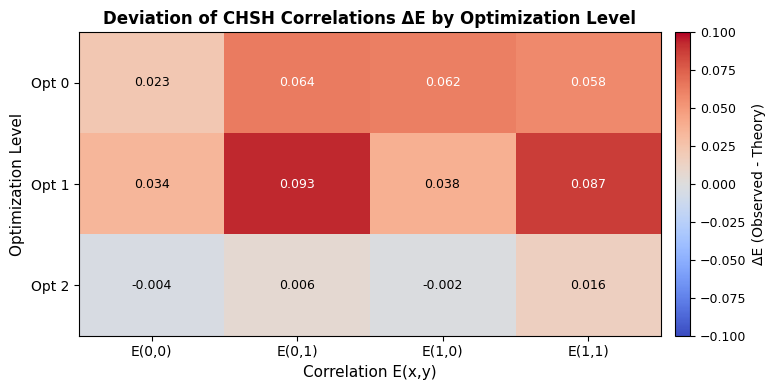

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# ΔE Heatmap (Formal Academic Style)
# =========================
corr_labels = ['E(0,0)', 'E(0,1)', 'E(1,0)', 'E(1,1)']
opt_levels = sorted(processed_results.keys())

# Build ΔE matrix
delta_E_matrix = np.array([
    processed_results[lvl]['E'] - np.array(E_theory)
    for lvl in opt_levels
])

plt.figure(figsize=(8,4))

# Use a formal academic colormap: coolwarm emphasizes positive/negative
im = plt.imshow(delta_E_matrix, cmap='coolwarm', vmin=-0.1, vmax=0.1, aspect='auto')

# Axes labels
plt.xticks(ticks=np.arange(len(corr_labels)), labels=corr_labels, fontsize=10)
plt.yticks(ticks=np.arange(len(opt_levels)), labels=[f'Opt {lvl}' for lvl in opt_levels], fontsize=10)

# Colorbar
cbar = plt.colorbar(im, label='ΔE (Observed - Theory)', pad=0.02)
cbar.ax.tick_params(labelsize=9)

# Annotate cells
for i in range(len(opt_levels)):
    for j in range(len(corr_labels)):
        val = delta_E_matrix[i, j]
        plt.text(j, i, f"{val:.3f}",
                 ha='center', va='center',
                 color='white' if abs(val) > 0.05 else 'black', fontsize=9)

# Titles and labels
plt.title('Deviation of CHSH Correlations ΔE by Optimization Level', fontsize=12, fontweight='bold')
plt.xlabel('Correlation E(x,y)', fontsize=11)
plt.ylabel('Optimization Level', fontsize=11)

# Optional: add subtle grid for clarity
plt.grid(False)  # paper style usually no grid
plt.tight_layout()
plt.show()